In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Car price dataset (2).csv')
df.head()

,Model,Year,Fuel_Type,Transmission,DoorsNum,Condition,Color,Cruise,Leather_Seats,Heated_Seats,...,Price,Cylinder_Numbers,Credit_History,Engine_Size,Weight,carlength,carwidth,monthly_mileage,peakrpm,Estimated_Mileage
0,Nissan Altima,2007,Petrol,Manual,4.0,Fair,Brown,No,No,No,...,8005.469674,two,0.004967,1.655688,3170.460434,179.1,68.1,3020.474750,6000,36245.697
1,Toyota Corolla,2019,Electric,Manual,4.0,Excellent,Beige,Yes,No,Yes,...,25385.241860,two,-0.001383,2.696626,3543.00629,182.1,60.0,894.742606,4689,10736.91127
2,Honda CR-V,2004,Petrol,Manual,4.0,Fair,Brown,No,No,No,...,6553.601733,three,0.006477,1.642471,3125.542396,161.0,67.5,3496.160436,5190,41953.92523
3,Toyota Corolla,2020,Electric,Manual,4.0,Good,Brown,Yes,Yes,Yes,...,24381.083350,three,0.015230,2.044309,3340.060049,169.7,65.2,1037.247974,5720,12446.97569
4,Toyota Tundra,2017,Hybrid,Automatic,4.0,Good,Brown,Yes,No,No,...,28357.830640,five,-0.002342,2.586011,3847.825597,176.0,68.1,880.045753,4559,10560.54904


In [3]:
df.describe()

,Year,DoorsNum,Owners,Warranty,Price,Credit_History,Engine_Size,carlength,carwidth,monthly_mileage,peakrpm
count,2230.000000,2223.000000,2230.000000,2230.000000,2230.000000,2230.000000,2230.000000,2230.000000,2230.000000,2230.000000,2230.000000
mean,2009.702242,3.640126,5.117489,19.735874,17241.511048,0.000360,2.931071,175.439552,66.477309,1986.593741,5343.346637
std,5.676737,2.318487,9.643330,8.419290,8961.471367,0.009869,9.195792,19.677468,3.770973,994.408364,722.580399
min,2000.000000,2.000000,0.000000,6.000000,3527.516896,-0.032413,1.000000,141.000000,60.000000,-326.426931,4100.000000
25%,2005.000000,2.000000,2.000000,13.000000,8897.953205,-0.006230,2.020221,158.500000,63.100000,1116.573719,4721.250000
50%,2009.000000,4.000000,2.000000,19.000000,17393.385485,0.000253,2.284103,175.600000,66.500000,1758.514301,5324.500000
75%,2014.000000,4.000000,3.000000,27.000000,24067.296380,0.006728,2.553892,192.575000,69.800000,2940.711792,5969.000000
max,2022.000000,44.000000,44.000000,35.000000,51219.220660,0.038527,152.348978,209.000000,73.000000,4167.599834,6600.000000


In [4]:
df.dtypes

Model                 object
Year                   int64
Fuel_Type             object
Transmission          object
DoorsNum             float64
Condition             object
Color                 object
Cruise                object
Leather_Seats         object
Heated_Seats          object
Navigation            object
Owners                 int64
Insurance             object
Service_History       object
Safety                object
Premium_Sound         object
Multimedia            object
Bluetooth             object
Wheel                 object
Sunroof               object
Warranty               int64
TAge                  object
Price                float64
Cylinder_Numbers      object
Credit_History       float64
Engine_Size          float64
Weight                object
carlength            float64
carwidth             float64
monthly_mileage      float64
peakrpm                int64
Estimated_Mileage     object
dtype: object

In [5]:
df = df.drop_duplicates()

In [6]:
df.shape

(2230, 32)

In [7]:
df.isna().sum()

Model                0
Year                 0
Fuel_Type            3
Transmission         7
DoorsNum             7
Condition            0
Color                2
Cruise               0
Leather_Seats        0
Heated_Seats         0
Navigation           0
Owners               0
Insurance            0
Service_History      0
Safety               0
Premium_Sound        0
Multimedia           0
Bluetooth            0
Wheel                0
Sunroof              0
Warranty             0
TAge                 0
Price                0
Cylinder_Numbers     0
Credit_History       0
Engine_Size          0
Weight               1
carlength            0
carwidth             0
monthly_mileage      0
peakrpm              0
Estimated_Mileage    0
dtype: int64

In [8]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()['Price']
corr_matrix

Year               0.623140
DoorsNum          -0.188311
Owners            -0.205366
Warranty           0.042927
Price              1.000000
Credit_History     0.013477
Engine_Size        0.038724
carlength          0.018720
carwidth          -0.018300
monthly_mileage   -0.952326
peakrpm           -0.014461
Name: Price, dtype: float64

In [9]:
#Data Preparation 
mis_cat = df[['Fuel_Type','Transmission','DoorsNum','Color']]
for col in mis_cat:
    df[col]= df[col].fillna(df[col].mode()[0])                   
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
num_cols = ['Weight']  # or more columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [10]:
df.isna().sum()

Model                0
Year                 0
Fuel_Type            0
Transmission         0
DoorsNum             0
Condition            0
Color                0
Cruise               0
Leather_Seats        0
Heated_Seats         0
Navigation           0
Owners               0
Insurance            0
Service_History      0
Safety               0
Premium_Sound        0
Multimedia           0
Bluetooth            0
Wheel                0
Sunroof              0
Warranty             0
TAge                 0
Price                0
Cylinder_Numbers     0
Credit_History       0
Engine_Size          0
Weight               0
carlength            0
carwidth             0
monthly_mileage      0
peakrpm              0
Estimated_Mileage    0
dtype: int64

### Modelling

In [11]:
#Feature Engineering
df['Car_Age']= 2025-df['Year']

In [12]:
df.columns

Index(['Model', 'Year', 'Fuel_Type', 'Transmission', 'DoorsNum', 'Condition',
       'Color', 'Cruise', 'Leather_Seats', 'Heated_Seats', 'Navigation',
       'Owners', 'Insurance', 'Service_History', 'Safety', 'Premium_Sound',
       'Multimedia', 'Bluetooth', 'Wheel', 'Sunroof', 'Warranty', 'TAge',
       'Price', 'Cylinder_Numbers', 'Credit_History', 'Engine_Size', 'Weight',
       'carlength', 'carwidth', 'monthly_mileage', 'peakrpm',
       'Estimated_Mileage', 'Car_Age'],
      dtype='object')

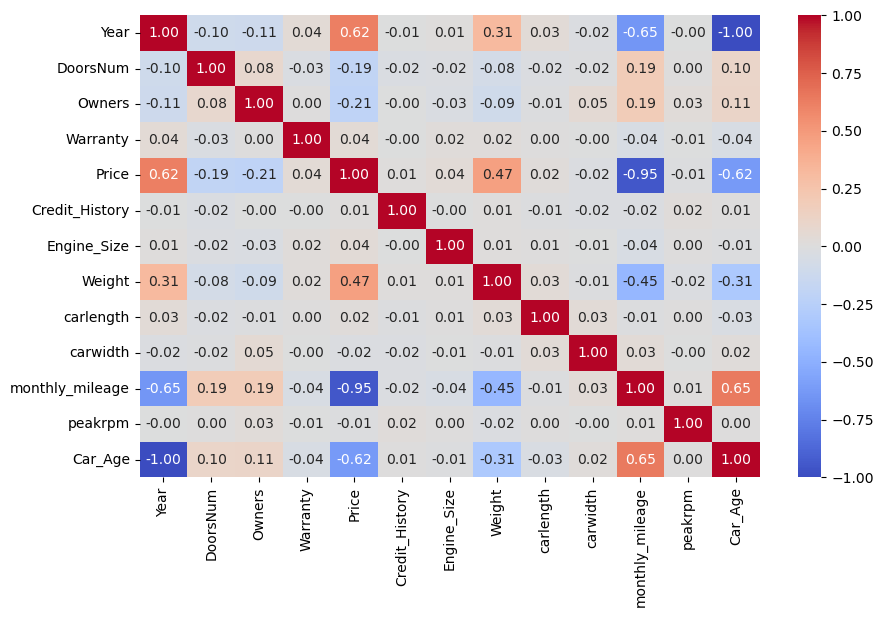

In [13]:
corr = df.corr(numeric_only=True)
plt.figure(figsize= (10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [15]:
X= df.drop('Price',axis=1)
y= df['Price']

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [19]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [20]:
results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="R2 Score", ascending=False))

              Model         RMSE  R2 Score
4      RandomForest  1484.907183  0.969221
5           XGBoost  1506.647046  0.968313
3        ElasticNet  2058.229175  0.940865
1             Ridge  2064.684486  0.940493
0  LinearRegression  2066.749124  0.940374
2             Lasso  2135.922864  0.936316


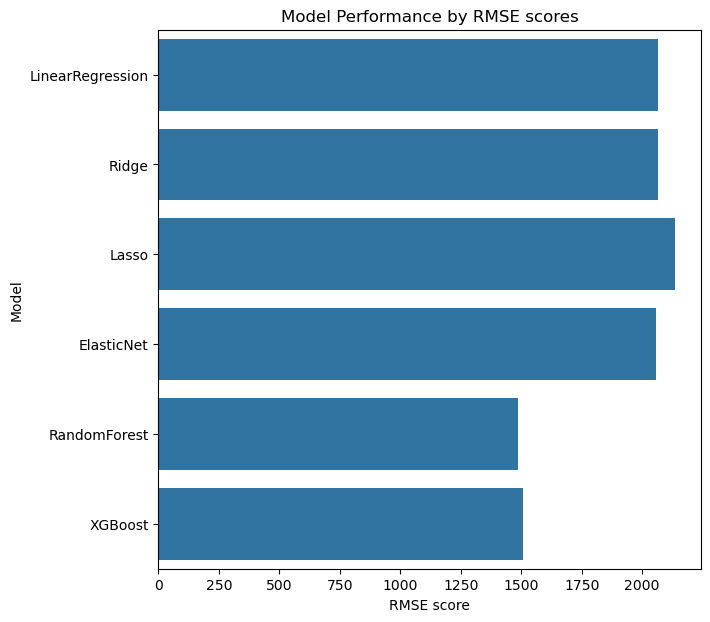

In [21]:
plt.figure(figsize=(7,7))
sns.barplot(data=results_df,y='Model',x='RMSE')
plt.title('Model Performance by RMSE scores')
plt.xlabel('RMSE score')
plt.ylabel('Model')
plt.show()

#### Hyperparameter tuning

In [22]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint,uniform

In [23]:
xgb_params = {
    "model__n_estimators": randint(100, 500),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__max_depth": randint(3, 10),
    "model__subsample": uniform(0.5, 0.5),
    "model__colsample_bytree": uniform(0.5, 0.5)
}

xgb_search = RandomizedSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(random_state=42))
    ]),
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

xgb_model = xgb_search.best_estimator_
yx_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, yx_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, yx_pred)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 1458.5012137910871
R2: 0.9703058395153669


In [24]:
rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ['sqrt', 'log2', None]
}


rf_search = RandomizedSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    param_distributions=rf_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
yr_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, yr_pred)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 1480.2241797553766
R2: 0.9694147207503011


### Model Performance Comparism

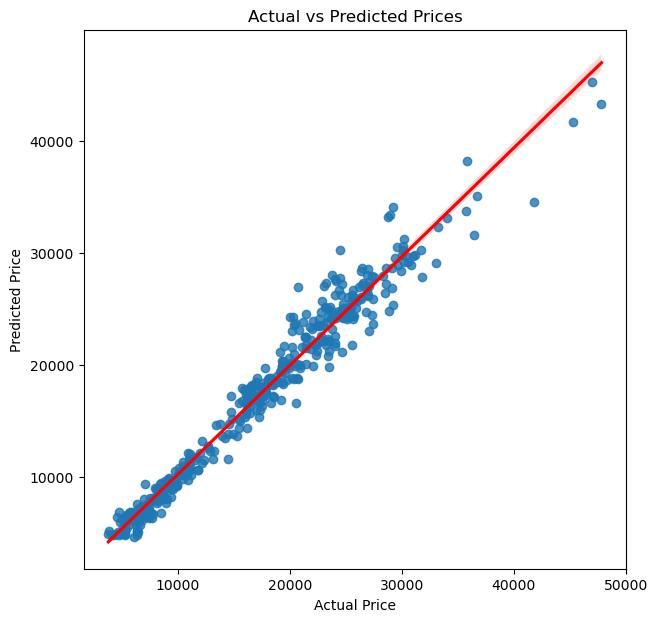

In [25]:
final_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": yr_pred
})

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,7))
sns.regplot(data=final_results, x="Actual", y="Predicted",line_kws={"color": "red"})

plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

#### Feature Importance

In [27]:
best_rf = rf_search.best_estimator_.named_steps['model']

ohe = rf_search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat']

cat_features = ohe.get_feature_names_out(cat_cols)

all_features = list(num_cols) + list(cat_features)

In [28]:
importances = best_rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
})

feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

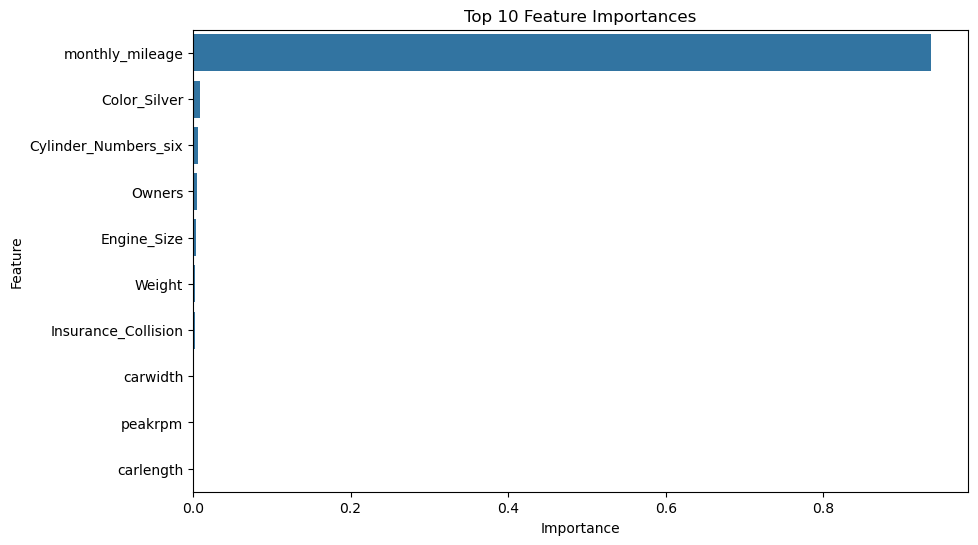

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feat_imp.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()

### Saving the model

In [31]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)